In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
valid_bookings = pd.read_parquet(BASE_DIR / r"_2_feature_engineering+momentum\start\valid_bookings_with_currency_and_google_restaurants_without_duplicates.parquet")
marketing_activities = pd.read_csv("master_marketing_activties.csv")


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------
# STEP 0A — Normalize booking datetime
# -----------------------
bookings = valid_bookings.copy()

# Prefer created_at if it's the booking creation timestamp; otherwise use start_time.
# (You can switch to 'start_time' if that's the actual dining time and you prefer that.)
bookings["booking_datetime"] = pd.to_datetime(bookings["created_at"], errors="coerce")

# If created_at missing, fallback to start_time
fallback = pd.to_datetime(bookings["start_time"], errors="coerce")
bookings["booking_datetime"] = bookings["booking_datetime"].fillna(fallback)

bookings = bookings.dropna(subset=["restaurant_id", "booking_datetime"]).copy()
bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")

# Optional: keep only active (if that's what you want)
# bookings = bookings.loc[bookings["active"].astype(bool)].copy()

# -----------------------
# STEP 0B — Normalize marketing activity times + restaurant_id
# -----------------------
mkt = marketing_activities.copy()

mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce")
mkt["activity_end"] = pd.to_datetime(mkt["activity_end"], errors="coerce")

# Create ONE restaurant_id column (covers CRM/KOL + FB multi-ids)
mkt["restaurant_id"] = (
    pd.to_numeric(mkt.get("crm_restaurant_id"), errors="coerce")
    .combine_first(pd.to_numeric(mkt.get("kol_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_2"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_3"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_4"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_5"), errors="coerce"))
)

# Drop any rows without proper window or restaurant
mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()

# Ensure start <= end
mkt = mkt.loc[mkt["activity_end"] >= mkt["activity_start"]].copy()

# Keep only columns needed for attribution (add more if you want)
mkt_exposure = mkt[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_ad_name"
]].copy()

# -----------------------
# STEP 0C — Interval join: bookings ↔ marketing exposure windows
# -----------------------
# 1) merge on restaurant_id to create candidates
cand = bookings[["id", "restaurant_id", "booking_datetime", "revenue_thb", "total_guests"]].merge(
    mkt_exposure,
    on="restaurant_id",
    how="left",
    suffixes=("_booking", "_mkt")
)

# 2) keep only where booking is inside [start, end]
attrib = cand[
    (cand["booking_datetime"] >= cand["activity_start"]) &
    (cand["booking_datetime"] <= cand["activity_end"])
].copy()

# -----------------------
# STEP 0D — Resolve overlaps (one booking → one activity)
# Choose the closest activity_start (most plausible driver)
# -----------------------
attrib["time_from_start_hours"] = (attrib["booking_datetime"] - attrib["activity_start"]).dt.total_seconds() / 3600.0
attrib["abs_time_from_start_hours"] = attrib["time_from_start_hours"].abs()

attrib = attrib.sort_values(["id", "abs_time_from_start_hours"])
attrib_1 = attrib.drop_duplicates(subset=["id"], keep="first").copy()

# -----------------------
# OUTPUTS
# -----------------------
OUT_DIR = Path.cwd()  # change if you want

# 1) booking-level attribution
attrib_1.to_csv(OUT_DIR / "booking_attribution_one_touch.csv", index=False)

# 2) optional: many-touch (if you want to analyse overlap)
attrib.to_csv(OUT_DIR / "booking_attribution_all_touches.csv", index=False)

# 3) quick sanity checks
print("Bookings:", bookings.shape)
print("Marketing exposures:", mkt_exposure.shape)
print("Attributed bookings (one-touch):", attrib_1.shape)

print("\nShare of bookings attributed:")
print(attrib_1["channel"].value_counts(dropna=False, normalize=True).head(10))

print("\nTop campaigns by attributed bookings:")
print(attrib_1.groupby(["channel", "activity_id"]).size().sort_values(ascending=False).head(10))


Bookings: (237458, 46)
Marketing exposures: (2167, 12)
Attributed bookings (one-touch): (6827, 18)

Share of bookings attributed:
channel
KOL    0.464919
CRM    0.385967
FB     0.149114
Name: proportion, dtype: float64

Top campaigns by attributed bookings:
channel  activity_id     
KOL      KOL_7b7b8ac5c14a    117
         KOL_fe57680c2d38     80
FB       FB_c3c9b5d07823      79
KOL      KOL_102d28159cf2     71
         KOL_98a8250efabc     69
         KOL_0b1926517a1d     68
FB       FB_2d1110ab34b5      61
KOL      KOL_f53950bcfddd     57
         KOL_1787394d00b4     55
         KOL_fd382d3c0771     55
dtype: int64


In [3]:
import pandas as pd
import numpy as np

# --- make sure bookings datetime is real datetime ---
bookings = bookings.copy()
bookings["booking_datetime"] = pd.to_datetime(bookings["booking_datetime"], errors="coerce")
bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")
bookings = bookings.dropna(subset=["booking_datetime", "restaurant_id"]).copy()

# --- make sure marketing activity times are real datetime ---
mkt = marketing_activities.copy()
mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce")
mkt["activity_end"]   = pd.to_datetime(mkt["activity_end"], errors="coerce")

# unify restaurant_id (since your marketing file has channel-specific cols)
mkt["restaurant_id"] = (
    pd.to_numeric(mkt.get("crm_restaurant_id"), errors="coerce")
    .combine_first(pd.to_numeric(mkt.get("kol_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_2"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_3"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_4"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_5"), errors="coerce"))
)

mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()
mkt = mkt.loc[mkt["activity_end"] >= mkt["activity_start"]].copy()

# 1️⃣ Count bookings during window (attrib_1 already exists)
during = attrib_1.groupby("activity_id").size().rename("bookings_during")

# 2️⃣ Build baseline window (same duration immediately BEFORE activity_start)
mkt["window_hours"] = (mkt["activity_end"] - mkt["activity_start"]).dt.total_seconds() / 3600.0

# guard: if any window_hours is 0/negative (shouldn't happen, but just in case)
mkt = mkt.loc[mkt["window_hours"] > 0].copy()

mkt["baseline_start"] = mkt["activity_start"] - pd.to_timedelta(mkt["window_hours"], unit="h")
mkt["baseline_end"]   = mkt["activity_start"]

# 3️⃣ Merge bookings to baseline window (candidate pairs by restaurant)
cand_baseline = bookings[["id", "restaurant_id", "booking_datetime"]].merge(
    mkt[["activity_id", "restaurant_id", "baseline_start", "baseline_end"]],
    on="restaurant_id",
    how="left"
)

baseline = cand_baseline[
    (cand_baseline["booking_datetime"] >= cand_baseline["baseline_start"]) &
    (cand_baseline["booking_datetime"] <  cand_baseline["baseline_end"])
].copy()

baseline_counts = baseline.groupby("activity_id").size().rename("bookings_baseline")

# 4️⃣ Combine → lift table
lift_table = pd.concat([during, baseline_counts], axis=1).fillna(0)
lift_table["lift"] = lift_table["bookings_during"] - lift_table["bookings_baseline"]
lift_table = lift_table.reset_index()

print(lift_table.head())
print(lift_table[["bookings_during","bookings_baseline","lift"]].describe())

lift_table

        activity_id  bookings_during  bookings_baseline  lift
0  CRM_00e026f097bf              1.0                0.0   1.0
1  CRM_032b8a82c4d2             28.0               46.0 -18.0
2  CRM_040ecc389a8b              2.0                6.0  -4.0
3  CRM_044d68c9632e              2.0                1.0   1.0
4  CRM_04cc1bcbe38f             13.0               22.0  -9.0
       bookings_during  bookings_baseline         lift
count      1189.000000        1189.000000  1189.000000
mean          5.741800           9.070648    -3.328848
std          10.075629          16.319311    14.113609
min           0.000000           0.000000  -170.000000
25%           0.000000           2.000000    -4.000000
50%           2.000000           4.000000    -1.000000
75%           7.000000          10.000000     1.000000
max         117.000000         249.000000    77.000000


,activity_id,bookings_during,bookings_baseline,lift
0,CRM_00e026f097bf,1.0,0.0,1.0
1,CRM_032b8a82c4d2,28.0,46.0,-18.0
2,CRM_040ecc389a8b,2.0,6.0,-4.0
3,CRM_044d68c9632e,2.0,1.0,1.0
4,CRM_04cc1bcbe38f,13.0,22.0,-9.0
...,...,...,...,...
1184,KOL_e62740c286dc,0.0,1.0,-1.0
1185,KOL_f43263ec15ba,0.0,3.0,-3.0
1186,KOL_f744554b3f49,0.0,57.0,-57.0
1187,KOL_fb2d79c3ce07,0.0,1.0,-1.0


In [4]:
# Keep 1 row per activity_id with key metadata
mkt_meta = mkt[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_ad_name", "fb_amount_spent_thb"
]].drop_duplicates("activity_id")

activity_perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# Add ROI-like metrics when possible (FB)
activity_perf["fb_amount_spent_thb"] = pd.to_numeric(activity_perf["fb_amount_spent_thb"], errors="coerce")
activity_perf["lift_per_1k_thb"] = np.where(
    (activity_perf["channel"] == "FB") & activity_perf["fb_amount_spent_thb"].gt(0),
    activity_perf["lift"] / (activity_perf["fb_amount_spent_thb"] / 1000.0),
    np.nan
)

activity_perf.to_csv(OUT_DIR / "activity_performance_lift.csv", index=False)
print(activity_perf.sort_values("lift", ascending=False).head(10))
activity_perf

          activity_id  bookings_during  bookings_baseline  lift channel  \
724  KOL_7b7b8ac5c14a            117.0               40.0  77.0     KOL   
757  KOL_98a8250efabc             69.0               18.0  51.0     KOL   
172  CRM_6946b4c6aa93             43.0               16.0  27.0     CRM   
351  CRM_be255b9edede             31.0                7.0  24.0     CRM   
750  KOL_928275c4f185             49.0               27.0  22.0     KOL   
262  CRM_9789612891d4             31.0               10.0  21.0     CRM   
838  KOL_eace1eaa251f             54.0               36.0  18.0     KOL   
864  KOL_fe57680c2d38             80.0               64.0  16.0     KOL   
593   FB_f462213127bc             49.0               34.0  15.0      FB   
20   CRM_0eb8d8f34ba4             23.0                8.0  15.0     CRM   

     restaurant_id      activity_start        activity_end  \
724         4089.0 2025-08-22 00:00:00 2025-08-27 00:00:00   
757         5196.0 2025-08-29 00:00:00 2025-09-03 

,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,crm_campaign_name,crm_topic,crm_audience,kol_platform,kol_username,kol_post_url,fb_ad_name,fb_amount_spent_thb,lift_per_1k_thb
0,CRM_00e026f097bf,1.0,0.0,1.0,CRM,3122.0,2025-09-26 17:00:00,2025-09-28 17:00:00,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,ssd-the-oasis-at-hotel-nikko-sep25,single,NaN,NaN,NaN,NaN,NaN,NaN
1,CRM_032b8a82c4d2,28.0,46.0,-18.0,CRM,370.0,2025-04-03 15:00:00,2025-04-05 15:00:00,TH_BKK_ctnoti_netcore_single_N_N_active_202504...,orchid-cafe-apr25,single,NaN,NaN,NaN,NaN,NaN,NaN
2,CRM_040ecc389a8b,2.0,6.0,-4.0,CRM,1747.0,2025-11-02 11:00:00,2025-11-04 11:00:00,TH_BKK_ctnoti_netcore_single_N_N_active_202511...,jumbo-seafood-sep25,single,NaN,NaN,NaN,NaN,NaN,NaN
3,CRM_044d68c9632e,2.0,1.0,1.0,CRM,280.0,2025-01-02 11:19:00,2025-01-04 11:19:00,TH_BKK_ctnoti_netcore_group_N_N_active_2025010...,weekly-new-week1-jan25,group,NaN,NaN,NaN,NaN,NaN,NaN
4,CRM_04cc1bcbe38f,13.0,22.0,-9.0,CRM,6462.0,2025-11-21 17:00:00,2025-11-23 17:00:00,TH_BKK_ctnoti_netcore_single_N_N_active_202511...,anchor-premium-buffet-nov25,single,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,KOL_e62740c286dc,0.0,1.0,-1.0,KOL,5711.0,2025-07-19 00:00:00,2025-07-24 00:00:00,NaN,NaN,NaN,Tiktok,giadinhcamcam,Tiktok.com/@giadinhcamcam,NaN,NaN,NaN
1185,KOL_f43263ec15ba,0.0,3.0,-3.0,KOL,1483.0,2025-09-24 00:00:00,2025-09-29 00:00:00,NaN,NaN,NaN,Tiktok,enjoyeating.tidpung,Tiktok.com/@enjoyeating.tidpung,NaN,NaN,NaN
1186,KOL_f744554b3f49,0.0,57.0,-57.0,KOL,5149.0,2025-08-09 00:00:00,2025-08-14 00:00:00,NaN,NaN,NaN,Tiktok,hubmeupscotty,Tiktok.com/@hubmeupscotty,NaN,NaN,NaN
1187,KOL_fb2d79c3ce07,0.0,1.0,-1.0,KOL,5349.0,2025-09-15 00:00:00,2025-09-20 00:00:00,NaN,NaN,NaN,Tiktok,brenttimmtravel,Tiktok.com/@brenttimmtravel,NaN,NaN,NaN


In [5]:
channel_summary = (
    activity_perf
    .groupby("channel", as_index=False)
    .agg(
        activities=("activity_id", "nunique"),
        total_bookings_during=("bookings_during", "sum"),
        total_baseline=("bookings_baseline", "sum"),
        total_lift=("lift", "sum"),
        avg_lift=("lift", "mean"),
        median_lift=("lift", "median"),
    )
)

channel_summary["lift_rate_vs_baseline"] = np.where(
    channel_summary["total_baseline"] > 0,
    channel_summary["total_lift"] / channel_summary["total_baseline"],
    np.nan
)

channel_summary.to_csv(OUT_DIR / "channel_summary.csv", index=False)
print(channel_summary)


  channel  activities  total_bookings_during  total_baseline  total_lift  \
0     CRM         558                 2635.0          2862.0      -227.0   
1      FB         322                 1018.0          4288.0     -3270.0   
2     KOL         309                 3174.0          3635.0      -461.0   

    avg_lift  median_lift  lift_rate_vs_baseline  
0  -0.406810         -1.0              -0.079315  
1 -10.155280         -3.0              -0.762593  
2  -1.491909          0.0              -0.126823  


OVERALL avg before: 9.07
OVERALL avg after : 5.74
OVERALL lift      : -3.33  (-36.7%)

CHANNEL summary (avg per activity):
  channel  avg_before  avg_after  n_activities   avg_lift   pct_lift
0     CRM    5.129032   4.722222           558  -0.406810  -7.931516
2     KOL   11.763754  10.271845           309  -1.491909 -12.682256
1      FB   13.316770   3.161491           322 -10.155280 -76.259328


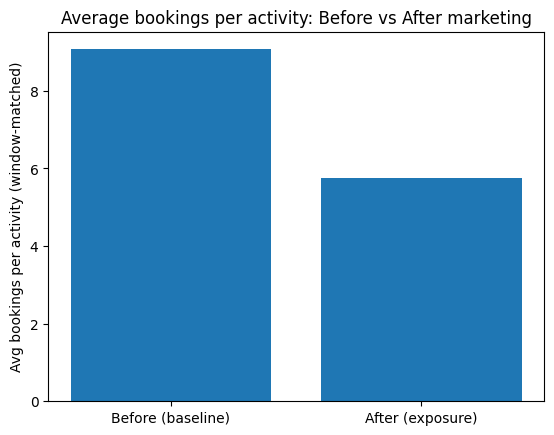

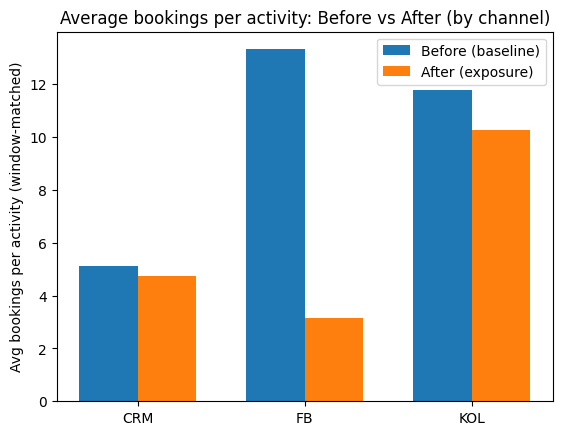

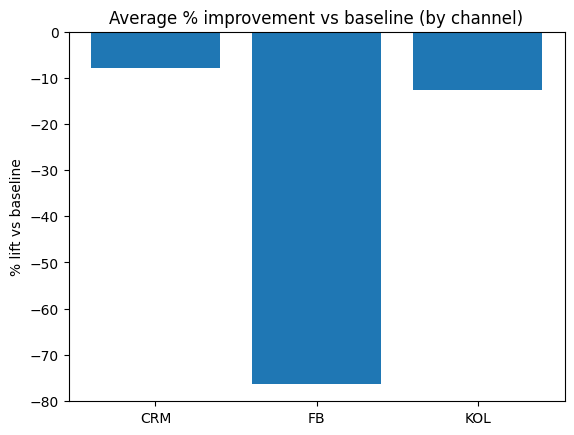

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Make sure you have these from your previous steps ---
# lift_table: columns = ["activity_id", "bookings_during", "bookings_baseline", "lift"]
# mkt: must contain ["activity_id", "channel"] and be 1 row per activity_id (or we'll dedupe)

mkt_meta = mkt[["activity_id", "channel"]].drop_duplicates("activity_id")
perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# --- 2) Overall averages ---
overall_before = perf["bookings_baseline"].mean()
overall_after  = perf["bookings_during"].mean()
overall_lift   = overall_after - overall_before
overall_pct    = np.nan if overall_before == 0 else (overall_lift / overall_before) * 100

print(f"OVERALL avg before: {overall_before:.2f}")
print(f"OVERALL avg after : {overall_after:.2f}")
print(f"OVERALL lift      : {overall_lift:.2f}  ({overall_pct:.1f}%)")

# --- 3) Channel averages (mean per activity) ---
channel_summary = (
    perf.groupby("channel", as_index=False)
        .agg(
            avg_before=("bookings_baseline", "mean"),
            avg_after=("bookings_during", "mean"),
            n_activities=("activity_id", "nunique"),
        )
)

channel_summary["avg_lift"] = channel_summary["avg_after"] - channel_summary["avg_before"]
channel_summary["pct_lift"] = np.where(
    channel_summary["avg_before"] > 0,
    (channel_summary["avg_lift"] / channel_summary["avg_before"]) * 100,
    np.nan
)

print("\nCHANNEL summary (avg per activity):")
print(channel_summary.sort_values("avg_lift", ascending=False))

# --- 4) Plot: Overall before vs after ---
plt.figure()
plt.bar(["Before (baseline)", "After (exposure)"], [overall_before, overall_after])
plt.title("Average bookings per activity: Before vs After marketing")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.show()

# --- 5) Plot: By channel (grouped bars) ---
# (no seaborn; no specified colors)
channels = channel_summary["channel"].tolist()
x = np.arange(len(channels))
w = 0.35

plt.figure()
plt.bar(x - w/2, channel_summary["avg_before"], width=w, label="Before (baseline)")
plt.bar(x + w/2, channel_summary["avg_after"],  width=w, label="After (exposure)")
plt.xticks(x, channels)
plt.title("Average bookings per activity: Before vs After (by channel)")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.legend()
plt.show()

# --- 6) Optional: Plot improvement (% lift) by channel ---
plt.figure()
plt.bar(channel_summary["channel"], channel_summary["pct_lift"])
plt.title("Average % improvement vs baseline (by channel)")
plt.ylabel("% lift vs baseline")
plt.show()
